# SIMPLACE run evaluation — phenology, LAI, yield

Compares simulated against observed **phenology**, **LAI** and **yield** for one crop,
with comparison plots and evaluation metrics (RMSE, MAE, R², bias) for each variable.

Set the crop in the configuration cell below and run all cells. The notebook finds the
run outputs and the observation files by itself: it reuses the same loaders the
calibration scripts use (`optimization/optimize_{phenology,lai,yield}.py`), so what you
see here is exactly what the optimizer scored.

Each of the three sections is independent — if a run has no output for one variable yet,
that section reports it and the rest still work.


## 1 · Configuration

The only cell you need to edit.


In [3]:
# ============================== CONFIGURATION ==============================
CROP = "winter_wheat"      # winter_wheat | winter_rapeseed | spring_barley | potato | maize

# Which run to evaluate.
#   None      -> auto: the calibration run for each variable if it has output,
#                otherwise the most recently written scenario run
#   "DWD__S1" -> a specific scenario run  (simplace/<crop>/runs/<id>/out/<id>/)
#   "optim:calib_growth/lai" -> a specific calibration run (one per view)
SOURCE = None

# Daily LAI output is tens of millions of rows for a full run; read an evenly
# spaced sample of this many locations instead.
MAX_LAI_LOCATIONS = 300

CONFIG_PATH = None         # None -> optimization/config.yaml
# ===========================================================================

## 2 · Setup

Imports, plot style, metrics, and run discovery.


In [4]:
import sys, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# --- locate the optimization package (works from anywhere in the repo) -----
here = Path.cwd()
OPTIM_DIR = next((p / "optimization" for p in [here, *here.parents]
                  if (p / "optimization" / "common.py").exists()), None)
if OPTIM_DIR is None:
    raise SystemExit("could not find optimization/common.py — run this from inside the repo")
sys.path.insert(0, str(OPTIM_DIR))

import common
import objectives

CONFIG = Path(CONFIG_PATH) if CONFIG_PATH else OPTIM_DIR / "config.yaml"
print(f"optimization package : {OPTIM_DIR}")
print(f"config               : {CONFIG}")

ModuleNotFoundError: No module named 'optimize_phenology'

In [3]:
# --------------------------- plot style -----------------------------------
# Two series only, so identity is fixed for the whole notebook:
#   observed = blue, simulated = orange. Never reassigned.
OBS, SIM = "#2a78d6", "#eb6834"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8880"
SURFACE, GRID = "#fcfcfb", "#e6e5e1"

# Single-hue sequential ramp for density (point clouds run to ~10^5 pairs).
DENSITY = LinearSegmentedColormap.from_list("blues", [
    "#eef4fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelsize": 9.5, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "grid.linestyle": "-", "grid.alpha": 1.0,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.0, "lines.markersize": 6,
    "figure.dpi": 110, "font.size": 10,
})

def style(ax, title=None, xlabel=None, ylabel=None):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

def one_to_one(ax, lo, hi, label=True):
    """Identity reference line — solid hairline, never a dashed 'grid'."""
    ax.plot([lo, hi], [lo, hi], color=MUTED, lw=1.0, zorder=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    if label:
        # Inside the axes, below the corner — outside it collides with the title.
        ax.annotate("1:1", (hi, hi), xytext=(-3, -13), textcoords="offset points",
                    ha="right", va="top", color=MUTED, fontsize=9)

def annotate_metrics(ax, m, loc="upper left"):
    """One compact block per panel — not a number on every point."""
    txt = (f"n = {m['n']:,}\nRMSE = {m['RMSE']:.2f}\nMAE = {m['MAE']:.2f}\n"
           f"R² = {m['R2']:.2f}\nbias = {m['Bias']:+.2f}")
    x, ha = (0.03, "left") if "left" in loc else (0.97, "right")
    y, va = (0.97, "top") if "upper" in loc else (0.03, "bottom")
    ax.text(x, y, txt, transform=ax.transAxes, ha=ha, va=va,
            fontsize=9, color=INK2, linespacing=1.5)

In [4]:
# --------------------------- metrics --------------------------------------
def metrics(obs, sim):
    """RMSE, MAE, R², bias (+ nRMSE% and Nash-Sutcliffe efficiency).

    R² is the squared Pearson correlation — how much of the observed variance the
    simulation tracks. EF additionally penalises being off the 1:1 line, so a model
    with high R² but a large bias shows up as high R² / low EF.
    """
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    ok = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[ok], sim[ok]
    if len(obs) < 2:
        return dict(n=len(obs), RMSE=np.nan, MAE=np.nan, R2=np.nan,
                    Bias=np.nan, nRMSE_pct=np.nan, EF=np.nan)
    err = sim - obs
    ss_tot = np.sum((obs - obs.mean()) ** 2)
    r = np.corrcoef(obs, sim)[0, 1] if obs.std() > 0 and sim.std() > 0 else np.nan
    return dict(
        n=int(len(obs)),
        RMSE=float(np.sqrt(np.mean(err ** 2))),
        MAE=float(np.mean(np.abs(err))),
        R2=float(r ** 2) if np.isfinite(r) else np.nan,
        Bias=float(err.mean()),
        nRMSE_pct=float(100 * np.sqrt(np.mean(err ** 2)) / obs.mean()) if obs.mean() else np.nan,
        EF=float(1 - np.sum(err ** 2) / ss_tot) if ss_tot > 0 else np.nan,
    )

def metrics_table(rows: dict) -> pd.DataFrame:
    return (pd.DataFrame(rows).T[["n", "RMSE", "MAE", "R2", "Bias", "nRMSE_pct", "EF"]]
            .rename(columns={"nRMSE_pct": "nRMSE %", "R2": "R²"})
            .round({"RMSE": 3, "MAE": 3, "R²": 3, "Bias": 3, "nRMSE %": 1, "EF": 3}))

RESULTS = {}   # variable -> metrics dict, collected for the summary

In [5]:
# --------------------------- locate the run -------------------------------
# Calibration runs in two stages; the three evaluated variables are the three
# views of those stages.
STAGE_OF = {"phenology": "phenology", "lai": "growth", "yield": "growth"}
spec_for = lambda view: common.load_spec(CONFIG, CROP, STAGE_OF[view], view=view)
CROP_DIR = spec_for("phenology").crop_dir
RUNS = common.discover_runs(CROP_DIR)

if not RUNS:
    raise SystemExit(f"no run output found under {CROP_DIR}/runs*/ — run a simulation first")

newest = max((lbl for lbl in RUNS if not lbl.startswith("optim:")),
             key=lambda l: RUNS[l].stat().st_mtime, default=None)

def pick(view):
    """Which run supplies this variable: its own calibration run, else the newest."""
    if SOURCE:
        if SOURCE not in RUNS:
            raise SystemExit(f"SOURCE={SOURCE!r} not found. Available: {sorted(RUNS)}")
        return SOURCE
    calibration = spec_for(view).out_dir
    label = next((lbl for lbl, out in RUNS.items() if out == calibration), None)
    return label or newest

print(f"crop: {CROP}   ({CROP_DIR})\n")
print(f"{len(RUNS)} run(s) with output:")
for lbl, out in RUNS.items():
    ny, nd = len(list(out.glob('yearly/*.csv'))), len(list(out.glob('daily/*.csv')))
    print(f"  {lbl:<24s} yearly={ny:>5,}  daily={nd:>5,}   {out}")

print("\nselected:")
USING = {v: pick(v) for v in STAGE_OF}
for v, lbl in USING.items():
    print(f"  {v:<10s} <- {lbl}")

def spec_at(view):
    """Spec for `view` whose outputs point at the selected run."""
    s = spec_for(view)
    s.out_override = RUNS[USING[view]]
    return s

crop: winter_wheat   (/data01/FDS/halder/soil-amelioration-scenarios/simplace/winter_wheat)

1 run(s) with output:
  DWD__S1                  yearly=3,086  daily=3,086   /data01/FDS/halder/soil-amelioration-scenarios/simplace/winter_wheat/runs/DWD__S1/out/DWD__S1

selected:
  phenology  <- DWD__S1
  lai        <- DWD__S1
  yield      <- DWD__S1


## 3 · Phenology

Simulated `AnthesisDOY` / `MaturityDOY` against observed flowering and maturity day-of-year,
joined on PointID + harvest year. Autumn-bolting location-years (simulated anthesis falling in
the calendar year _before_ harvest) are excluded — a known weather-driven model artifact that
would otherwise put ~300-day errors into the metrics.


In [6]:
try:
    ph_spec = spec_at("phenology")
    phen = objectives.phenology_process_result(ph_spec)
    n_bolting = phen.attrs.get("n_bolting", 0)
    print(f"{len(phen):,} matched location-years across {phen['PointID'].nunique():,} points"
          f"   ({n_bolting:,} excluded as autumn bolting)")

    PHEN_M = {
        "flowering DOY": metrics(phen["flowering_doy"], phen["flowering_doy_sim"]),
        "maturity DOY":  metrics(phen["maturity_doy"],  phen["maturity_doy_sim"]),
    }
    RESULTS.update({f"phenology · {k}": v for k, v in PHEN_M.items()})
    display(metrics_table(PHEN_M))
except Exception as exc:
    phen = None
    print(f"phenology unavailable: {type(exc).__name__}: {exc}")

135,241 matched location-years across 3,085 points   (1 excluded as autumn bolting)


,n,RMSE,MAE,R²,Bias,nRMSE %,EF
flowering DOY,135241.0,15.938,12.281,0.292,1.722,10.4,-1.330
maturity DOY,135241.0,14.522,11.192,0.338,0.195,6.6,-0.449


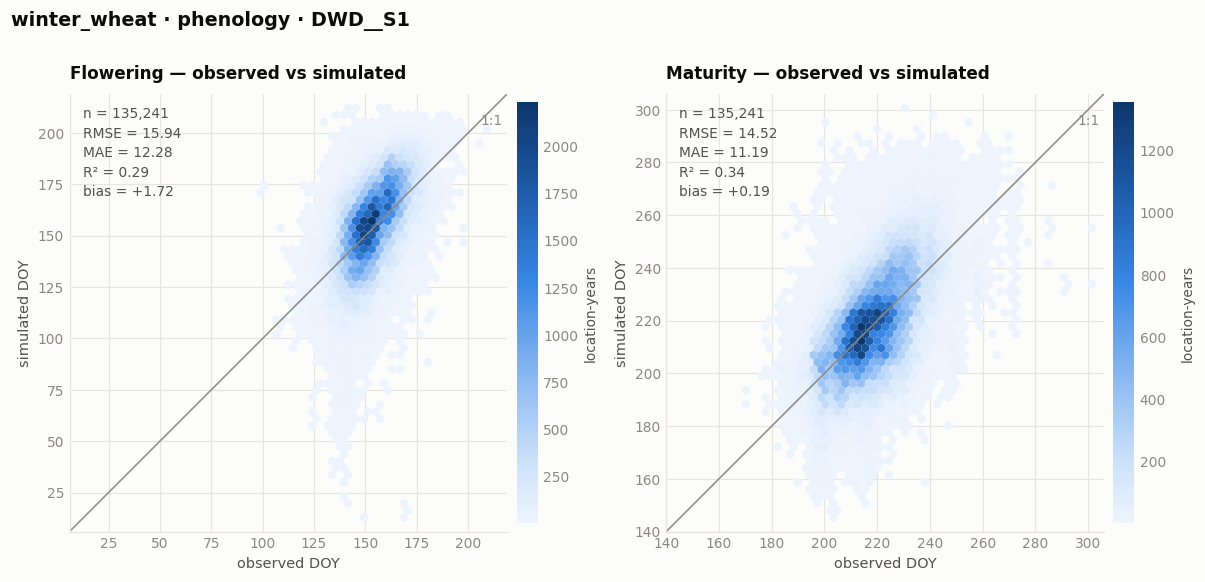

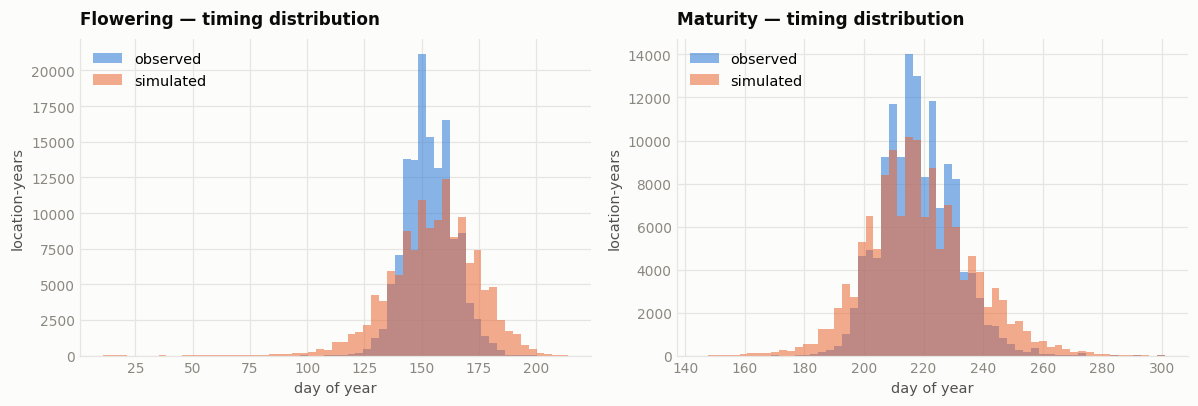

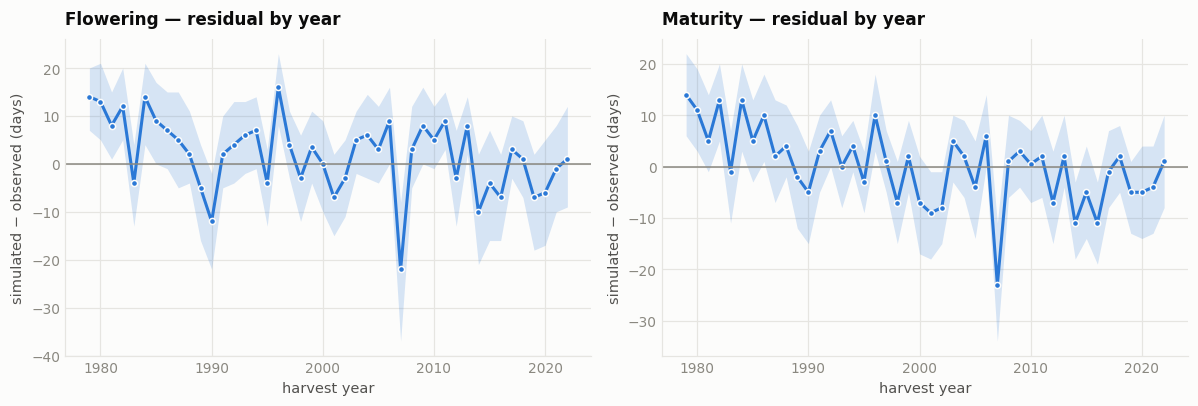

In [7]:
if phen is not None:
    pairs = [("flowering", "flowering_doy", "flowering_doy_sim"),
             ("maturity",  "maturity_doy",  "maturity_doy_sim")]

    # --- observed vs simulated, as density (10^5 pairs would be a solid blob) ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
    for ax, (name, o, s) in zip(axes, pairs):
        lo = float(min(phen[o].min(), phen[s].min())) - 5
        hi = float(max(phen[o].max(), phen[s].max())) + 5
        hb = ax.hexbin(phen[o], phen[s], gridsize=55, cmap=DENSITY,
                       mincnt=1, linewidths=0, extent=(lo, hi, lo, hi))
        one_to_one(ax, lo, hi)
        annotate_metrics(ax, PHEN_M[f"{name} DOY"])
        style(ax, f"{name.capitalize()} — observed vs simulated",
              "observed DOY", "simulated DOY")
        cb = fig.colorbar(hb, ax=ax, pad=0.02, fraction=0.045)
        cb.set_label("location-years", color=INK2, fontsize=9)
        cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=MUTED)
    fig.suptitle(f"{CROP} · phenology · {USING['phenology']}",
                 x=0.008, ha="left", fontsize=12.5, color=INK, weight="semibold")
    fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

    # --- timing distributions: two series, so legend + fixed identity ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for ax, (name, o, s) in zip(axes, pairs):
        bins = np.linspace(min(phen[o].min(), phen[s].min()),
                           max(phen[o].max(), phen[s].max()), 60)
        ax.hist(phen[o], bins=bins, color=OBS, alpha=0.55, label="observed")
        ax.hist(phen[s], bins=bins, color=SIM, alpha=0.55, label="simulated")
        style(ax, f"{name.capitalize()} — timing distribution", "day of year", "location-years")
        ax.legend(loc="upper left")
    fig.tight_layout(); plt.show()

    # --- residual by year: one series per panel -> small multiples, one hue ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
    for ax, (name, o, s) in zip(axes, pairs):
        d = phen.assign(resid=phen[s] - phen[o])
        g = d.groupby("harvest_year")["resid"]
        med, q1, q3 = g.median(), g.quantile(0.25), g.quantile(0.75)
        ax.fill_between(med.index, q1, q3, color=OBS, alpha=0.18, linewidth=0)
        ax.plot(med.index, med.values, color=OBS, marker="o", markersize=4,
                markeredgecolor=SURFACE, markeredgewidth=1.0)
        ax.axhline(0, color=MUTED, lw=1.0)
        style(ax, f"{name.capitalize()} — residual by year", "harvest year",
              "simulated − observed (days)")
    fig.tight_layout(); plt.show()

### Mean phenology by state and by year

Grouped bars, observed vs simulated, with ±1 SD whiskers and each series' overall mean as a
reference line — the comparison from the earlier per-crop notebooks, restyled to this
notebook's palette. Both panels share one category order (sorted by observed flowering) so
the two variables line up column for column.

Bars start at zero: their length encodes the value, so a truncated axis would exaggerate the
observed–simulated gap. The differences are easier to read in the residual and 1:1 panels above.


In [8]:
def attach_state(df, target="phenology"):
    """Add the federal state to a phenology frame, from the selected run's project table."""
    run_dir = RUNS[USING[target]].parents[1]          # <run_dir>/out/<exp> -> <run_dir>
    src = next((p for p in (run_dir / "project" / "project.csv",
                            CROP_DIR / "project" / f"project_{CROP}.csv") if p.exists()), None)
    if src is None:
        raise FileNotFoundError("no project table found for the selected run")
    proj = (pd.read_csv(src, sep=";", usecols=["vLocationID", "vSTATE_NAME"])
            .drop_duplicates()
            .rename(columns={"vLocationID": "PointID", "vSTATE_NAME": "state"}))
    return df.merge(proj, on="PointID", how="inner")


def grouped_bars(ax, cats, stats, ylabel, title, rotation=45):
    """Observed vs simulated bars with ±1 SD whiskers and per-series mean lines."""
    x = np.arange(len(cats))
    w = 0.38                                   # pair sits inside 0.38*2 + gap
    ekw = dict(ecolor=MUTED, elinewidth=1.0, capsize=0)
    ax.bar(x - w / 2 - 0.012, stats["obs_mu"], w, yerr=stats["obs_sd"],
           color=OBS, label="observed", linewidth=0, error_kw=ekw)
    ax.bar(x + w / 2 + 0.012, stats["sim_mu"], w, yerr=stats["sim_sd"],
           color=SIM, label="simulated", linewidth=0, error_kw=ekw)
    # Overall means: solid hairlines, identity carried by colour not by dashing.
    ax.axhline(stats["obs_mu"].mean(), color=OBS, lw=1.2, zorder=1)
    ax.axhline(stats["sim_mu"].mean(), color=SIM, lw=1.2, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=rotation,
                       ha="right" if rotation not in (0, 90) else "center")
    ax.grid(axis="x", visible=False)
    ax.margins(x=0.01)
    return style(ax, title, None, ylabel)


def agg_pair(df, by, obs_col, sim_col, order=None):
    s = df.groupby(by).agg(obs_mu=(obs_col, "mean"), obs_sd=(obs_col, "std"),
                           sim_mu=(sim_col, "mean"), sim_sd=(sim_col, "std"))
    return s.reindex(order) if order is not None else s

PHEN_VARS = [("Flowering", "flowering_doy", "flowering_doy_sim"),
             ("Maturity",  "maturity_doy",  "maturity_doy_sim")]

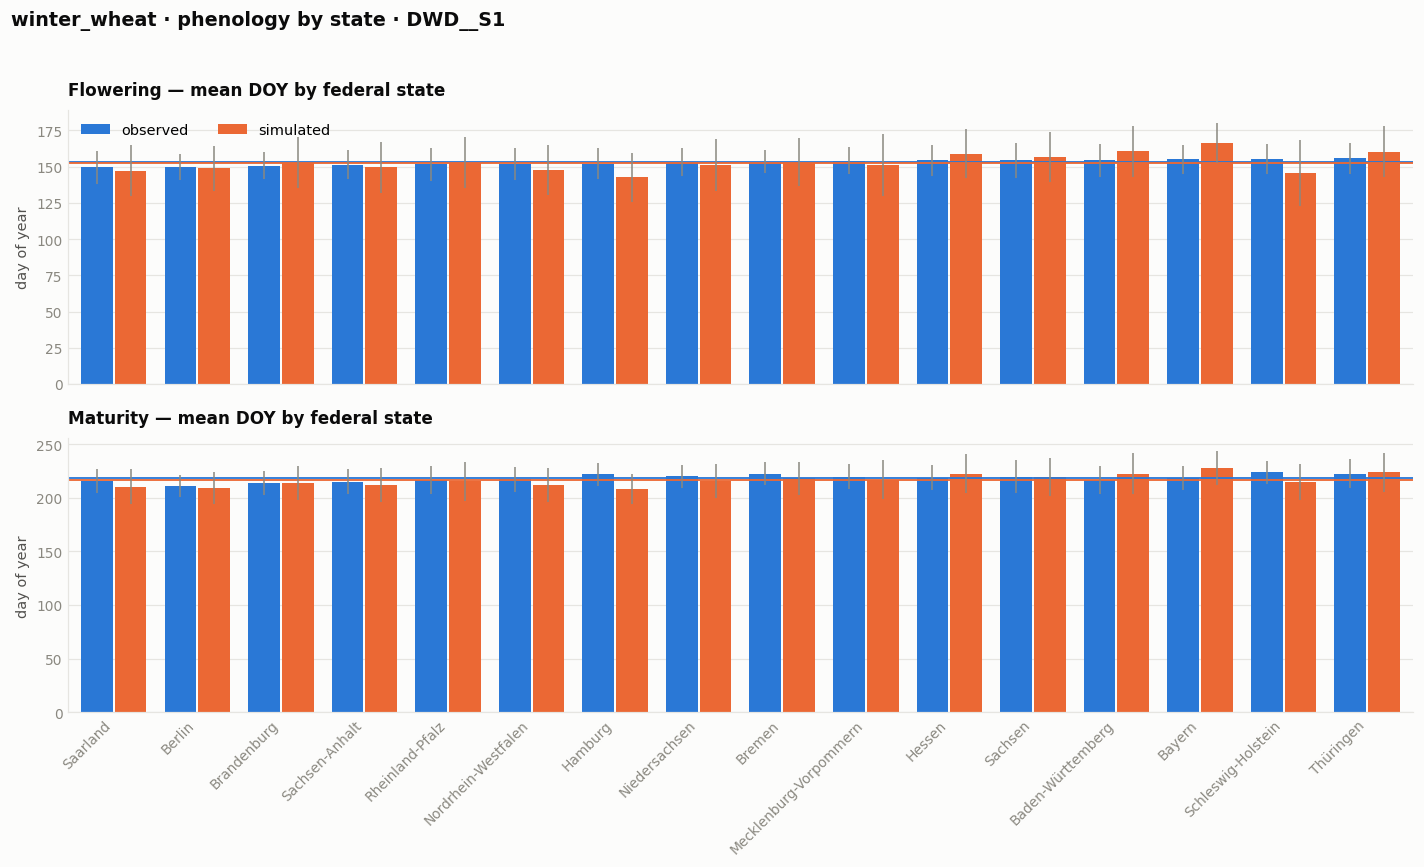

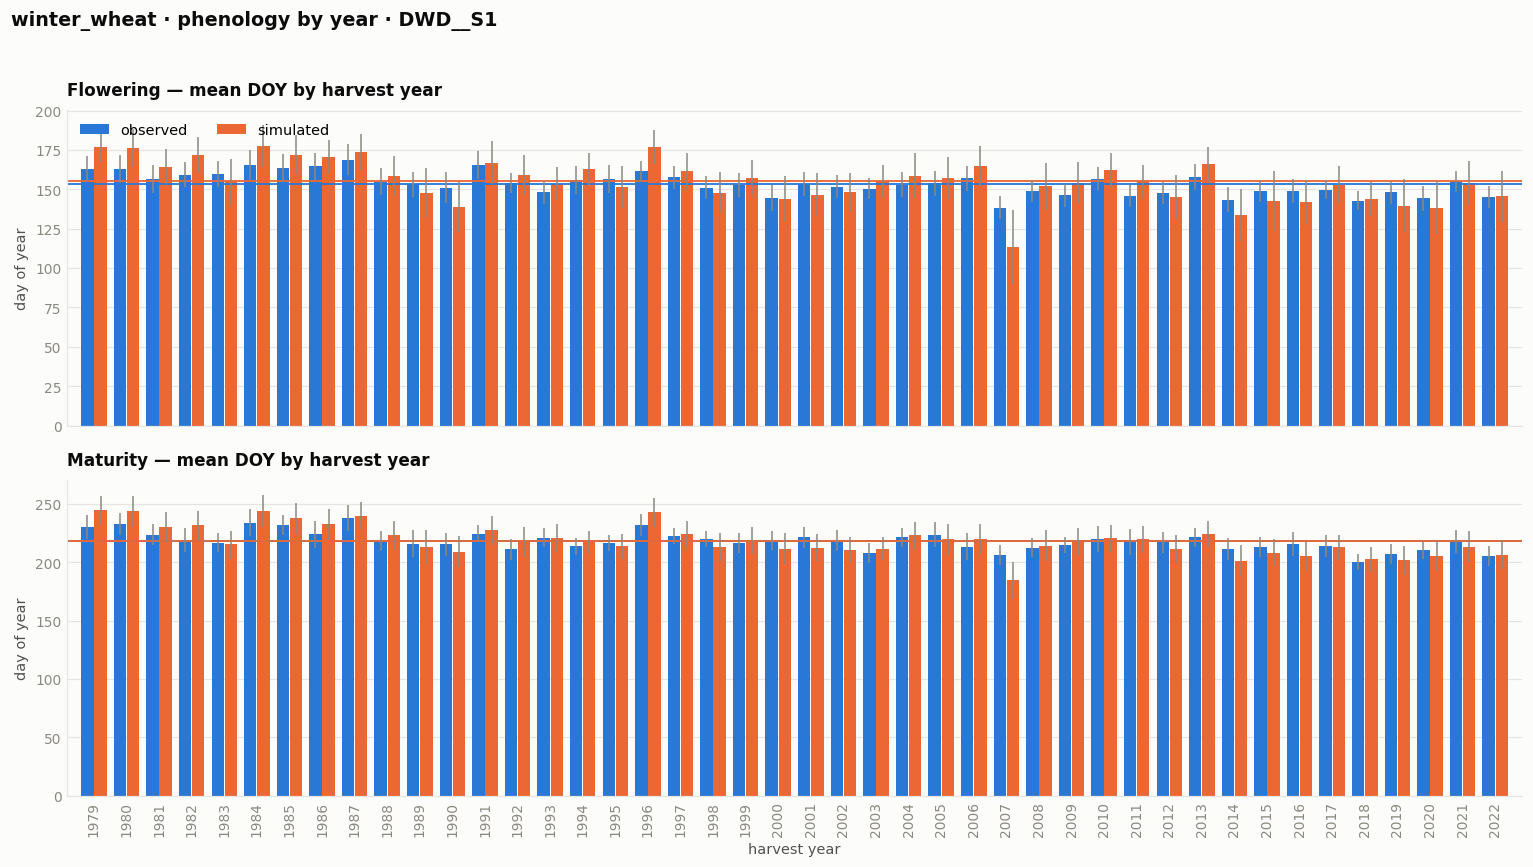

In [9]:
if phen is not None:
    ph_state = attach_state(phen)

    # --- by federal state -------------------------------------------------
    order = (ph_state.groupby("state")["flowering_doy"].mean()
             .sort_values().index)                       # one order for both panels
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    for ax, (name, o, s) in zip(axes, PHEN_VARS):
        st = agg_pair(ph_state, "state", o, s, order)
        grouped_bars(ax, order, st, "day of year", f"{name} — mean DOY by federal state")
    axes[0].legend(loc="upper left", ncols=2)
    fig.suptitle(f"{CROP} · phenology by state · {USING['phenology']}",
                 x=0.008, ha="left", fontsize=12.5, color=INK, weight="semibold")
    fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

    # --- by harvest year --------------------------------------------------
    years = sorted(phen["harvest_year"].unique())
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for ax, (name, o, s) in zip(axes, PHEN_VARS):
        st = agg_pair(phen, "harvest_year", o, s, years)
        grouped_bars(ax, years, st, "day of year", f"{name} — mean DOY by harvest year",
                     rotation=90)
    axes[0].legend(loc="upper left", ncols=2)
    axes[1].set_xlabel("harvest year")
    fig.suptitle(f"{CROP} · phenology by year · {USING['phenology']}",
                 x=0.008, ha="left", fontsize=12.5, color=INK, weight="semibold")
    fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

## 4 · LAI

Simulated daily LAI against the GLASS-LAI retrievals, joined on location + date and
truncated at physiological maturity (DVS ≥ 2).

The metrics are reported twice: on the **raw daily pairs**, and on **DVS-binned means** —
the latter is the quantity `optimize_lai.py` minimises, because raw daily retrievals are
noisy and unevenly spread across the season, so binning by development stage weights each
phase of the canopy trajectory equally.

> The LAI observations belong to their own point set and weather grid. Evaluating LAI from a
> _scenario_ run (rather than `optim:lai`) matches far fewer points; the cell warns when that
> happens.


In [10]:
try:
    lai_spec = spec_at("lai")
    sim_d = common.read_outputs(lai_spec.out_dir, "daily", limit=MAX_LAI_LOCATIONS)
    sim_d = sim_d[sim_d["DevStage"] > 0].copy()
    sim_d["DATE"] = pd.to_datetime(sim_d["DATE"], format="%d.%m.%Y")
    sim_d = (sim_d[["Location", "Year", "DATE", "DevStage", "LAI"]]
             .sort_values(["Location", "DATE"]).reset_index(drop=True)
             .pipe(objectives.truncate_at_maturity)
             .rename(columns={"Location": "location", "Year": "year", "DATE": "date",
                              "DevStage": "dvs", "LAI": "LAI_sim"}))
    obs_l = pd.read_csv(lai_spec.crop_dir / "data_observed" / f"LAI_{CROP}.csv",
                        parse_dates=["date"])
    lai = sim_d.merge(obs_l, on=["location", "date"], how="inner")

    if lai.empty:
        raise RuntimeError("no observed/simulated LAI pairs matched")
    print(f"{len(lai):,} matched daily pairs across {lai['location'].nunique():,} locations "
          f"(read {sim_d['location'].nunique():,} simulated locations)")
    if lai["location"].nunique() < 0.5 * sim_d["location"].nunique():
        print(f"  ⚠ only {lai['location'].nunique():,} of the simulated locations carry LAI "
              f"observations — this run's point set is not the LAI calibration set. "
              f"Use the growth stage's LAI run for a like-for-like evaluation.")

    lai_agg = objectives.aggregate_by_dvs(lai, objectives.DVS_BINS)
    LAI_M = {
        "LAI (daily pairs)": metrics(lai["LAI"], lai["LAI_sim"]),
        "LAI (DVS-binned)":  metrics(lai_agg["LAI_obs_mean"], lai_agg["LAI_sim_mean"]),
    }
    RESULTS.update({f"lai · {k}": v for k, v in LAI_M.items()})
    display(metrics_table(LAI_M))
except Exception as exc:
    lai = None
    print(f"LAI unavailable: {type(exc).__name__}: {exc}")

55 matched daily pairs across 1 locations (read 300 simulated locations)
  ⚠ only 1 of the simulated locations carry LAI observations — this run's point set is not the LAI calibration set. Use SOURCE='optim:lai' for a like-for-like LAI evaluation.


,n,RMSE,MAE,R²,Bias,nRMSE %,EF
LAI (daily pairs),55.0,1.001,0.741,0.353,-0.701,58.4,-0.407
LAI (DVS-binned),7.0,0.780,0.660,0.687,-0.660,34.3,-0.156


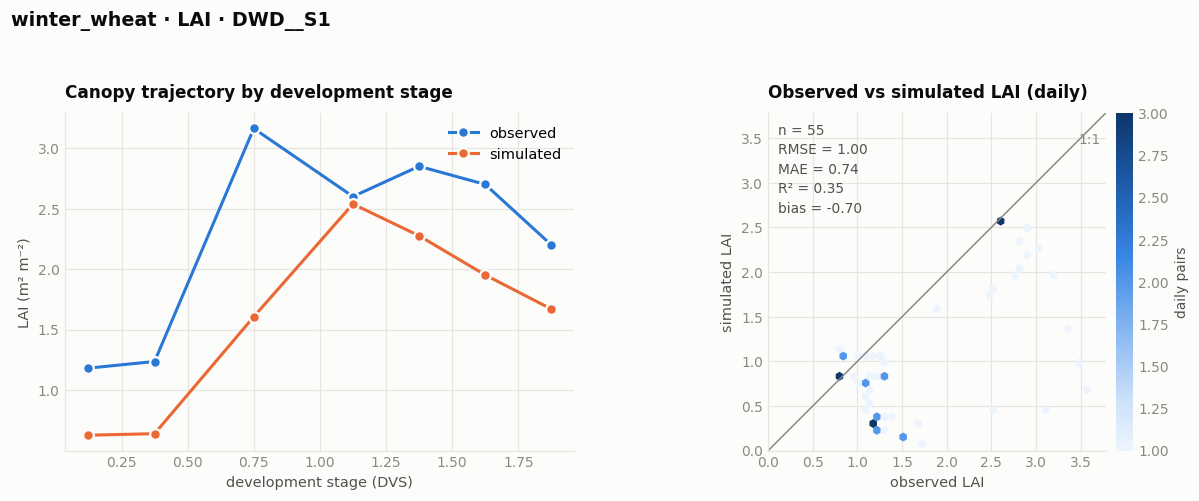

In [11]:
if lai is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

    # --- canopy trajectory by development stage: two series -> legend ---
    ax = axes[0]
    t = (lai_agg.groupby("dvs_bin", observed=True)[["LAI_obs_mean", "LAI_sim_mean"]]
         .agg(["mean", "std"]).sort_index())
    x = [iv.mid for iv in t.index]   # bin midpoint on the DVS axis
    for col, colour, label in ((("LAI_obs_mean"), OBS, "observed"),
                               (("LAI_sim_mean"), SIM, "simulated")):
        mu, sd = t[(col, "mean")].values, np.nan_to_num(t[(col, "std")].values)
        ax.fill_between(x, mu - sd, mu + sd, color=colour, alpha=0.15, linewidth=0)
        ax.plot(x, mu, color=colour, marker="o", markersize=7,
                markeredgecolor=SURFACE, markeredgewidth=1.5, label=label)
    style(ax, "Canopy trajectory by development stage",
          "development stage (DVS)", "LAI (m² m⁻²)")
    ax.legend(loc="upper right")

    # --- observed vs simulated ---
    ax = axes[1]
    hi = float(max(lai["LAI"].max(), lai["LAI_sim"].max())) * 1.05
    hb = ax.hexbin(lai["LAI"], lai["LAI_sim"], gridsize=45, cmap=DENSITY,
                   mincnt=1, linewidths=0, extent=(0, hi, 0, hi))
    one_to_one(ax, 0, hi)
    annotate_metrics(ax, LAI_M["LAI (daily pairs)"])
    style(ax, "Observed vs simulated LAI (daily)", "observed LAI", "simulated LAI")
    cb = fig.colorbar(hb, ax=ax, pad=0.02, fraction=0.045)
    cb.set_label("daily pairs", color=INK2, fontsize=9)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=MUTED)

    fig.suptitle(f"{CROP} · LAI · {USING['lai']}", x=0.008, ha="left",
                 fontsize=12.5, color=INK, weight="semibold")
    fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

    # --- seasonal course, one panel per year ---
    years = sorted(lai["year"].unique())
    if len(years) > 1:
        n = len(years); ncol = min(n, 4); nrow = int(np.ceil(n / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.7 * nrow),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, yr in zip(axes.ravel(), years):
            d = lai[lai["year"] == yr]
            doy = d["date"].dt.dayofyear
            for col, colour, label in (("LAI", OBS, "observed"), ("LAI_sim", SIM, "simulated")):
                s = d.assign(doy=doy).groupby("doy")[col].mean()
                ax.plot(s.index, s.values, color=colour, lw=1.8, label=label)
            style(ax, str(yr), "day of year", "LAI")
        for ax in axes.ravel()[len(years):]:
            ax.set_visible(False)
        axes.ravel()[0].legend(loc="upper left")
        fig.suptitle("Mean seasonal LAI course by year", x=0.008, ha="left",
                     fontsize=12.5, color=INK, weight="semibold")
        fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

## 5 · Yield

Observed yield is **district-level** (one row per NUTS-3 region and year) while the model runs
per point, so simulated points are averaged to NUTS-3 before joining on region + year.
Reported at three scales — district-year, yearly means (temporal skill) and state means
(spatial skill) — because a parameter set can match the national mean while flattening either
dimension.

Observed yield is put on the model's dry-matter basis using `dm_fraction` from
`optimization/config.yaml` (1.0 for the cereals and rapeseed; potato observations are fresh
tuber weight, so 0.21).


In [12]:
try:
    y_spec = spec_at("yield")
    if y_spec.dm_fraction != 1.0:
        print(f"observed yield scaled by dm_fraction = {y_spec.dm_fraction} (fresh -> dry matter)")
    yld = objectives.yield_process_result(y_spec)
    if yld.empty:
        raise RuntimeError("no observed/simulated yield pairs matched")

    by_year  = yld.groupby("year")[["yield", "yield_sim"]].mean()
    by_state = yld.groupby("STATE_NAME")[["yield", "yield_sim"]].mean()

    print(f"{len(yld):,} district-years across {yld['NUTS_ID'].nunique():,} districts, "
          f"{yld['year'].min()}-{yld['year'].max()}")

    YIELD_M = {
        "district-year": metrics(yld["yield"], yld["yield_sim"]),
        "yearly means":  metrics(by_year["yield"], by_year["yield_sim"]),
        "state means":   metrics(by_state["yield"], by_state["yield_sim"]),
    }
    RESULTS.update({f"yield · {k}": v for k, v in YIELD_M.items()})
    display(metrics_table(YIELD_M))
except Exception as exc:
    yld = None
    print(f"yield unavailable: {type(exc).__name__}: {exc}")

9,147 district-years across 210 districts, 1979-2023


,n,RMSE,MAE,R²,Bias,nRMSE %,EF
district-year,9147.0,2.133,1.711,0.002,-0.338,32.1,-1.367
yearly means,45.0,1.177,0.957,0.013,-0.361,17.7,-0.600
state means,13.0,0.993,0.782,0.065,-0.404,15.1,-0.837


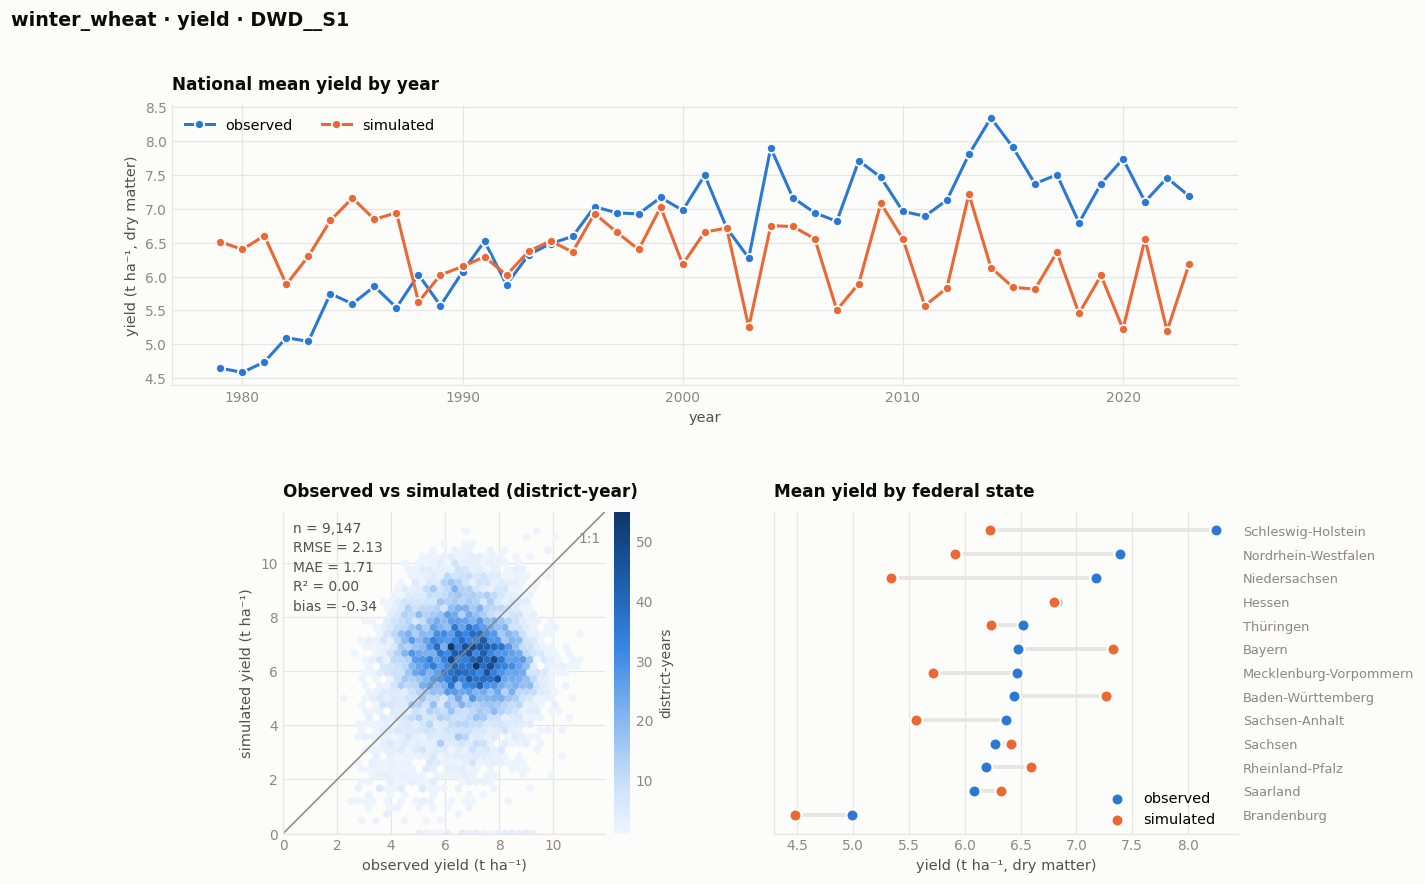

In [14]:
if yld is not None:
    fig = plt.figure(figsize=(12.5, 8.6))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.42, wspace=0.30)

    # --- temporal: two series on ONE axis ---
    ax = fig.add_subplot(gs[0, :])
    ax.plot(by_year.index, by_year["yield"], color=OBS, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.2, label="observed")
    ax.plot(by_year.index, by_year["yield_sim"], color=SIM, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.2, label="simulated")
    style(ax, "National mean yield by year", "year", "yield (t ha⁻¹, dry matter)")
    ax.legend(loc="best", ncols=2)

    # --- observed vs simulated at district-year ---
    ax = fig.add_subplot(gs[1, 0])
    hi = float(max(yld["yield"].max(), yld["yield_sim"].max())) * 1.05
    hb = ax.hexbin(yld["yield"], yld["yield_sim"], gridsize=45, cmap=DENSITY,
                   mincnt=1, linewidths=0, extent=(0, hi, 0, hi))
    one_to_one(ax, 0, hi)
    annotate_metrics(ax, YIELD_M["district-year"])
    style(ax, "Observed vs simulated (district-year)",
          "observed yield (t ha⁻¹)", "simulated yield (t ha⁻¹)")
    cb = fig.colorbar(hb, ax=ax, pad=0.02, fraction=0.045)
    cb.set_label("district-years", color=INK2, fontsize=9)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=MUTED)

    # --- spatial: dumbbell, observed vs simulated per state ---
    ax = fig.add_subplot(gs[1, 1])
    s = by_state.sort_values("yield")
    ypos = np.arange(len(s))
    ax.hlines(ypos, s["yield"], s["yield_sim"], color=GRID, lw=2.5, zorder=1)
    ax.scatter(s["yield"], ypos, s=64, color=OBS, zorder=3,
               edgecolor=SURFACE, linewidth=1.5, label="observed")
    ax.scatter(s["yield_sim"], ypos, s=64, color=SIM, zorder=3,
               edgecolor=SURFACE, linewidth=1.5, label="simulated")
    ax.set_yticks(ypos); ax.set_yticklabels(s.index, fontsize=8.5)
    # State names are long; on the left they run into the neighbouring colorbar.
    ax.yaxis.tick_right()
    ax.set_ylim(-0.8, len(s) - 0.2)
    ax.grid(axis="y", visible=False)
    style(ax, "Mean yield by federal state", "yield (t ha⁻¹, dry matter)", None)
    ax.legend(loc="lower right", bbox_to_anchor=(0.98, -0.02))

    fig.suptitle(f"{CROP} · yield · {USING['yield']}", x=0.008, ha="left",
                 fontsize=12.5, color=INK, weight="semibold")
    plt.show()

## 6 · Summary

Every metric computed above, in one table.


In [14]:
if RESULTS:
    summary = metrics_table(RESULTS)
    display(summary)
    print("\nRMSE/MAE/bias are in the units of each variable (days, m² m⁻², t ha⁻¹).")
    print("R² = squared Pearson correlation; EF = Nash-Sutcliffe efficiency (1.0 = on the 1:1 line,")
    print("<= 0 = no better than predicting the observed mean). A high R² with a low EF means the")
    print("model tracks the pattern but sits off the 1:1 line — look at bias.")
else:
    print("nothing evaluated — no run output was found for any variable")

,n,RMSE,MAE,R²,Bias,nRMSE %,EF
phenology · flowering DOY,135241.0,15.938,12.281,0.292,1.722,10.4,-1.330
phenology · maturity DOY,135241.0,14.522,11.192,0.338,0.195,6.6,-0.449
lai · LAI (daily pairs),55.0,0.910,0.666,0.454,-0.495,53.1,-0.163
lai · LAI (DVS-binned),7.0,0.565,0.454,0.721,-0.174,24.8,0.393
yield · district-year,9147.0,2.134,1.711,0.002,-0.177,32.2,-1.371
yield · yearly means,45.0,1.144,0.911,0.016,-0.201,17.2,-0.513
yield · state means,13.0,0.922,0.752,0.072,-0.242,14.0,-0.583



RMSE/MAE/bias are in the units of each variable (days, m² m⁻², t ha⁻¹).
R² = squared Pearson correlation; EF = Nash-Sutcliffe efficiency (1.0 = on the 1:1 line,
<= 0 = no better than predicting the observed mean). A high R² with a low EF means the
model tracks the pattern but sits off the 1:1 line — look at bias.


In [15]:
# Optional: write the summary next to the run being evaluated.
SAVE = False
if SAVE and RESULTS:
    out = OPTIM_DIR / "results" / f"evaluation_{CROP}.csv"
    out.parent.mkdir(parents=True, exist_ok=True)
    summary.assign(crop=CROP, source=[USING.get(k.split(" · ")[0], "") for k in summary.index]
                   ).to_csv(out)
    print(f"written: {out}")